In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_excel("../Dataset/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].shape

(9288, 8)

In [9]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [10]:
(df['UnitPrice'] <= 0).sum()

np.int64(2517)

In [11]:
df['CustomerID'].isnull().sum()

np.int64(135080)

In [12]:
df_clean = df.copy()

# Remove rows without CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove cancelled transactions
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

# Keep only positive quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# Keep only positive prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Reset index
df_clean = df_clean.reset_index(drop=True)

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))

Original rows: 541909
Cleaned rows: 397884


In [13]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[us]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 29.3+ MB


In [14]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [15]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))

Original rows: 541909
Cleaned rows: 397884


In [17]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [18]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [19]:
df_clean['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [20]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [21]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [22]:
rfm.shape

(4338, 3)

In [23]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [24]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [25]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [26]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

In [27]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [28]:
rfm.shape

(4338, 3)

In [37]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


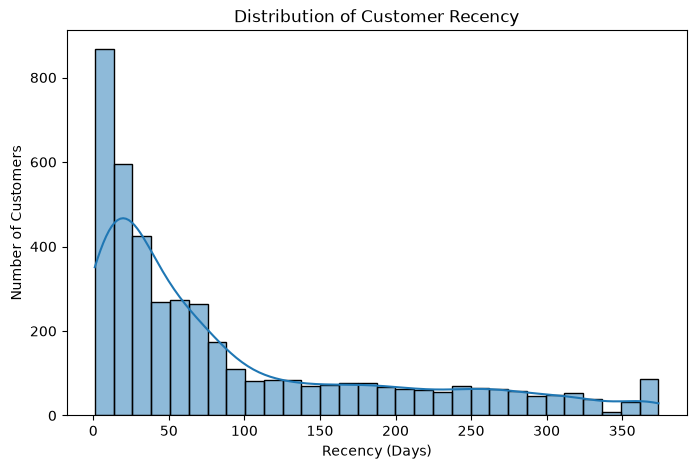

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Distribution of Customer Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.show()

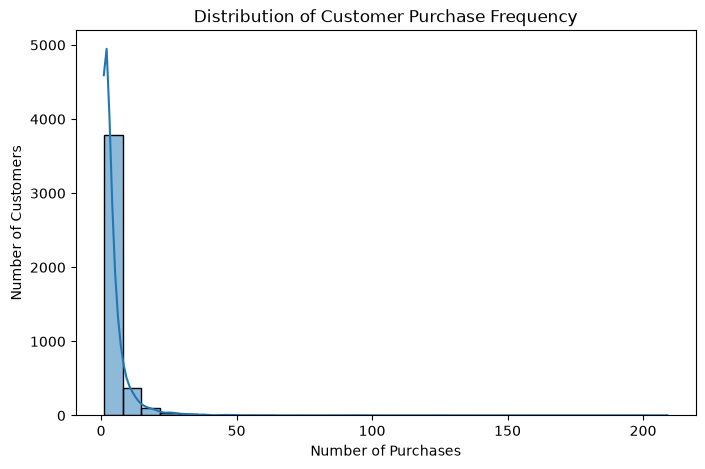

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title('Distribution of Customer Purchase Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()

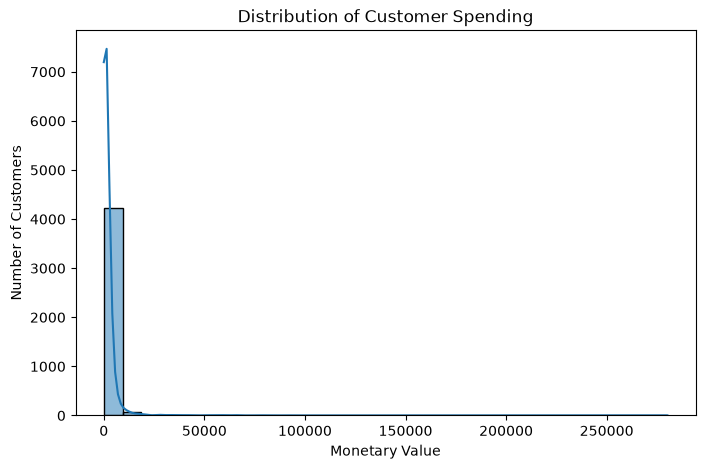

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Distribution of Customer Spending')
plt.xlabel('Monetary Value')
plt.ylabel('Number of Customers')
plt.show()

In [32]:
rfm_model = rfm.copy()

for column in ['Recency', 'Frequency', 'Monetary']:
    Q1 = rfm_model[column].quantile(0.25)
    Q3 = rfm_model[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    rfm_model[column] = rfm_model[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

rfm_model.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.00000,4338.000000
mean,91.447441,3.48663,1162.912410
std,97.199547,3.04011,1148.071634
min,1.000000,1.00000,3.750000
25%,18.000000,1.00000,307.415000
50%,51.000000,2.00000,674.485000
75%,142.000000,5.00000,1661.740000
max,328.000000,11.00000,3693.227500


In [33]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_model[['Recency', 'Frequency', 'Monetary']]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm_model.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.413382,-0.818035,2.204224
12347.0,-0.920352,1.155805,2.204224
12348.0,-0.169233,0.168885,0.552579
12349.0,-0.745433,-0.818035,0.518004
12350.0,2.248753,-0.818035,-0.721739


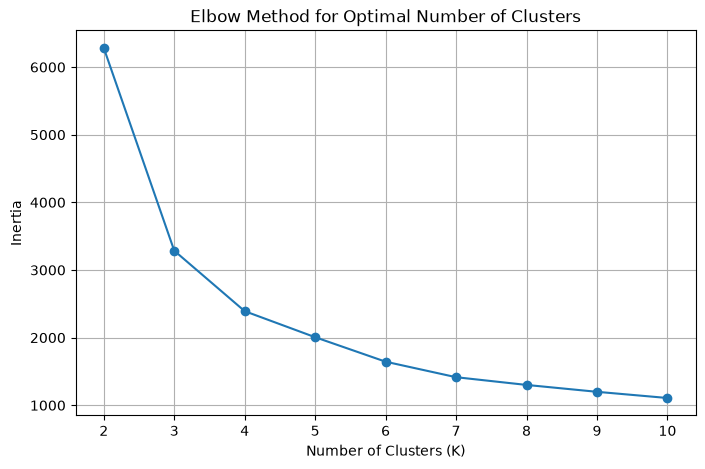

In [34]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K)
plt.grid(True)
plt.show()

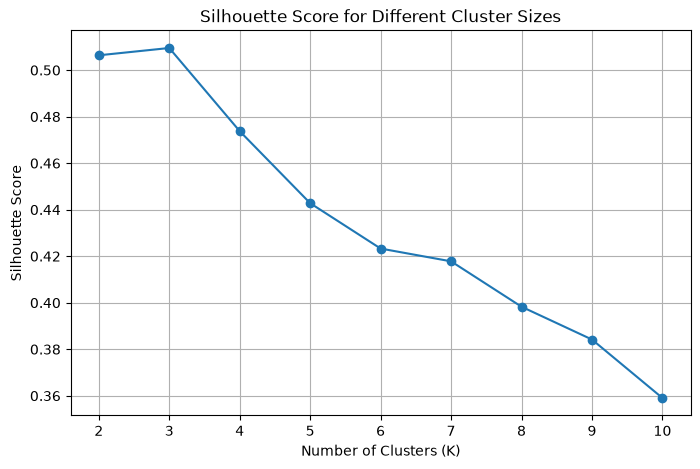

In [35]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score for Different Cluster Sizes')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [36]:
best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("Best K based on Silhouette Score:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best K based on Silhouette Score: 3
Best Silhouette Score: 0.5095124208345764


In [38]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm_model['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm_model.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,3693.2275,2
12347.0,2,7,3693.2275,1
12348.0,75,4,1797.2400,0
12349.0,19,1,1757.5500,0
12350.0,310,1,334.4000,2


In [39]:
rfm_model['Cluster'].value_counts().sort_index()

Cluster
0    2327
1     962
2    1049
Name: count, dtype: int64

In [40]:
cluster_summary = rfm_model.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,48.97,2.46,731.49
1,26.90,8.16,3008.21
2,244.86,1.47,427.68


In [41]:
rfm_model['Cluster'].value_counts().sort_index()

Cluster
0    2327
1     962
2    1049
Name: count, dtype: int64

In [42]:
cluster_summary = rfm_model.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,48.97,2.46,731.49
1,26.90,8.16,3008.21
2,244.86,1.47,427.68


In [43]:
cluster_names = {
    0: 'Regular Customers',
    1: 'High-Value Customers',
    2: 'At-Risk Customers'
}

rfm_model['Segment'] = rfm_model['Cluster'].map(cluster_names)

rfm_model.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,3693.2275,2,At-Risk Customers
12347.0,2,7,3693.2275,1,High-Value Customers
12348.0,75,4,1797.2400,0,Regular Customers
12349.0,19,1,1757.5500,0,Regular Customers
12350.0,310,1,334.4000,2,At-Risk Customers


In [44]:
segment_counts = rfm_model['Segment'].value_counts()

segment_counts

Segment
Regular Customers       2327
At-Risk Customers       1049
High-Value Customers     962
Name: count, dtype: int64

In [45]:
segment_percentage = (
    rfm_model['Segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_percentage

Segment
Regular Customers       53.64
At-Risk Customers       24.18
High-Value Customers    22.18
Name: proportion, dtype: float64

In [46]:
customer_segments = rfm_model.reset_index()

customer_segments.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,3693.2275,2,At-Risk Customers
1,12347.0,2,7,3693.2275,1,High-Value Customers
2,12348.0,75,4,1797.2400,0,Regular Customers
3,12349.0,19,1,1757.5500,0,Regular Customers
4,12350.0,310,1,334.4000,2,At-Risk Customers


In [47]:
customer_segments.to_csv(
    "../PowerBI/customer_segments.csv",
    index=False
)

In [48]:
customer_behavior = df_clean.groupby('CustomerID').agg(
    Country=('Country', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'),
    TotalItems=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique'),
    TotalTransactions=('InvoiceNo', 'nunique')
).reset_index()

customer_behavior.head()

,CustomerID,Country,TotalItems,UniqueProducts,TotalTransactions
0,12346.0,United Kingdom,74215,1,1
1,12347.0,Iceland,2458,103,7
2,12348.0,Finland,2341,22,4
3,12349.0,Italy,631,73,1
4,12350.0,Norway,197,17,1


In [49]:
customer_segments = customer_segments.merge(
    customer_behavior,
    on='CustomerID',
    how='left'
)

customer_segments.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment,Country,TotalItems,UniqueProducts,TotalTransactions
0,12346.0,326,1,3693.2275,2,At-Risk Customers,United Kingdom,74215,1,1
1,12347.0,2,7,3693.2275,1,High-Value Customers,Iceland,2458,103,7
2,12348.0,75,4,1797.2400,0,Regular Customers,Finland,2341,22,4
3,12349.0,19,1,1757.5500,0,Regular Customers,Italy,631,73,1
4,12350.0,310,1,334.4000,2,At-Risk Customers,Norway,197,17,1


In [50]:
customer_segments['AvgOrderValue'] = (
    customer_segments['Monetary'] /
    customer_segments['TotalTransactions']
)

customer_segments[['CustomerID', 'Monetary', 'TotalTransactions', 'AvgOrderValue']].head()

,CustomerID,Monetary,TotalTransactions,AvgOrderValue
0,12346.0,3693.2275,1,3693.227500
1,12347.0,3693.2275,7,527.603929
2,12348.0,1797.2400,4,449.310000
3,12349.0,1757.5500,1,1757.550000
4,12350.0,334.4000,1,334.400000


In [51]:
customer_segments.to_csv(
    "../PowerBI/customer_segments.csv",
    index=False
)

print("Final Power BI dataset saved successfully!")
print("Rows:", len(customer_segments))
print("Columns:", len(customer_segments.columns))

Final Power BI dataset saved successfully!
Rows: 4338
Columns: 11


In [52]:
product_segment = df_clean.merge(
    customer_segments[['CustomerID', 'Segment']],
    on='CustomerID',
    how='inner'
)

product_segment.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,High-Value Customers
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,High-Value Customers
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,High-Value Customers
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,High-Value Customers
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,High-Value Customers


In [53]:
top_products = (
    product_segment
    .groupby(['Segment', 'Description'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Segment', 'Quantity'], ascending=[True, False])
)

top_products.head(20)

,Segment,Description,Quantity
1487,At-Risk Customers,MEDIUM CERAMIC TOP STORAGE JAR,74288
2794,At-Risk Customers,WORLD WAR 2 GLIDERS ASSTD DESIGNS,5041
2440,At-Risk Customers,SMALL POPCORN HOLDER,4741
162,At-Risk Customers,ASSORTED COLOURS SILK FAN,3392
1529,At-Risk Customers,MINI PAINT SET VINTAGE,2053
2727,At-Risk Customers,WHITE HANGING HEART T-LIGHT HOLDER,1999
1979,At-Risk Customers,RED HARMONICA IN BOX,1791
1685,At-Risk Customers,PACK OF 72 RETROSPOT CAKE CASES,1766
2145,At-Risk Customers,ROUND SNACK BOXES SET OF 4 FRUITS,1616
394,At-Risk Customers,BROCADE RING PURSE,1593


In [54]:
top_products.to_csv(
    "../PowerBI/product_preferences.csv",
    index=False
)

print("Product preference dataset saved!")

Product preference dataset saved!


In [55]:
segment_summary = customer_segments.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum')
).round(2)

segment_summary

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue
Segment,,,,,
At-Risk Customers,1049,244.86,1.47,427.68,448637.74
High-Value Customers,962,26.90,8.16,3008.21,2893902.43
Regular Customers,2327,48.97,2.46,731.49,1702173.86


In [56]:
segment_summary

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue
Segment,,,,,
At-Risk Customers,1049,244.86,1.47,427.68,448637.74
High-Value Customers,962,26.90,8.16,3008.21,2893902.43
Regular Customers,2327,48.97,2.46,731.49,1702173.86
